# Environment objects modifiers

Here we illustrate the usage of modifiers, that allow to rotate and shift all environment objects (fields, zones, lasers, ...). 

For more information, checkout the API documentation for ``atomsmltr.environment.modifiers``

## with scalar objects

### lasers

Let's play with lasers and modifiers. Note however that all degrees of freedom for lasers can be directly controlled when defining the laser beam, so in general one should not have to use modifiers.

**ATTENTION** currently laser polarization is not handled well with rotation modifiers, so we advise not to use it with laser beams.

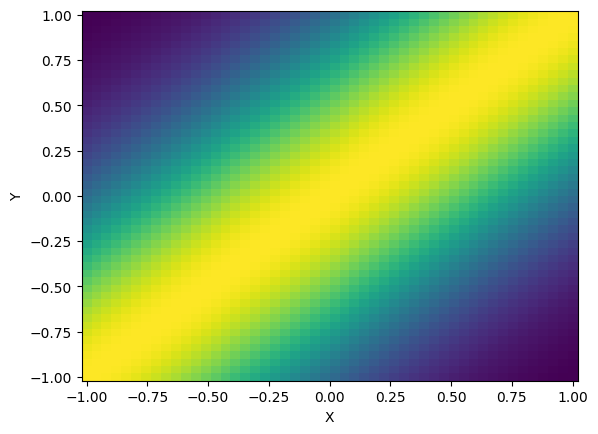

In [20]:
# - create a laser propagating along x, and rotate it by π/2
import numpy as np
from atomsmltr.environment import GaussianLaserBeam
from atomsmltr.environment.modifiers import rotate

laser = GaussianLaserBeam(direction=(1, 0, 0))
rotate(laser, (0, 0, 1), np.pi / 4)
ax = laser.plot2D((-1e-3, 1e-3, -1e-3, 1e-3), (50, 50), space_scale=1e3, plane="XY")

### zones

Modifiers can be useful to create zones that are not natively supported by ``atomsmtlr``.

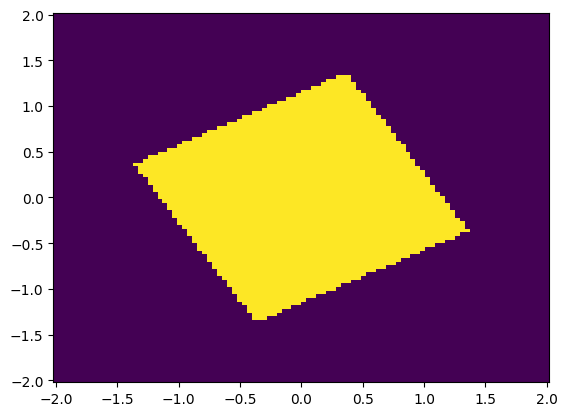

In [ ]:
# - create a box and rotate it
# imports
import numpy as np
import matplotlib.pyplot as plt
from atomsmltr.environment import Box
from atomsmltr.environment.modifiers import rotate

# define box
box = Box(-1, 1, -1, 1, -1, 1)

# rotate
rotate(box, (0, 0, 1), np.pi / 6)

# compute values and plot
pos = np.squeeze(np.mgrid[-2:2:100j, -2:2:101j, 0:0:1j]).T
value = box.get_value(pos)


# plot
X, Y, _ = pos.T
plt.figure()
plt.pcolormesh(X.T, Y.T, value)
plt.show()

## with vector objects

Modifiers also work with vector fields, such as magnetic fields or forces. In this case, the field is also rotated, as one would expect.

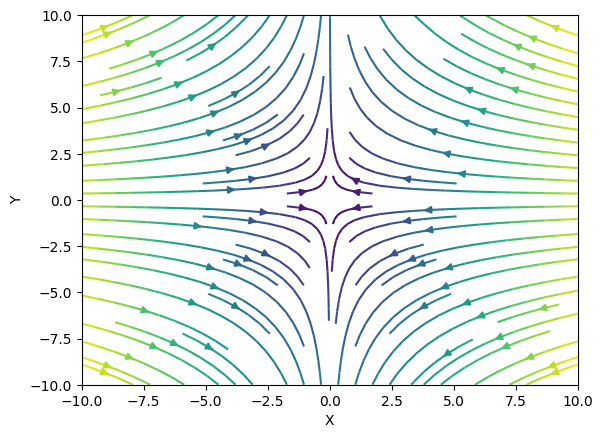

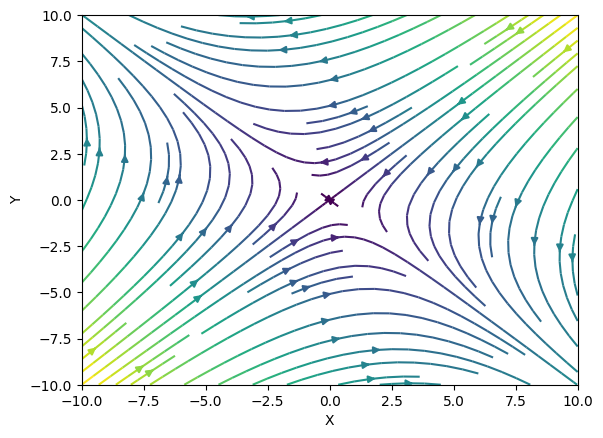

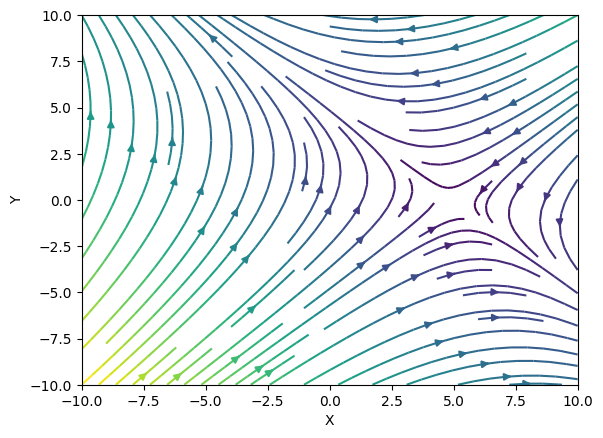

In [21]:
import numpy as np
from atomsmltr.environment import MagneticQuadrupoleX
from atomsmltr.environment.modifiers import rotate, shift

# create a quadrupole field
field = MagneticQuadrupoleX((0,0,0), 1)
field.plot2D((-10, 10, -10, 10), (50, 50), plane="XY")

# rotate
rotate(field, (0,0,1), np.pi/4)
field.plot2D((-10, 10, -10, 10), (50, 50), plane="XY")

# shift
shift(field, (5,0,0))
ax = field.plot2D((-10, 10, -10, 10), (50, 50), plane="XY")